## 1. Import Required Libraries

Importing essential Python libraries for data manipulation and analysis.

In [1]:
# Import core libraries for data manipulation, numerical operations, and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load raw dataset from the data directory

df = pd.read_csv("../data/processed/clean_shipping_data.csv")

## 8. Route Definition

Since factory data is unavailable, defining route as:

Division → State/Province

This represents production category to customer destination mapping.

In [3]:
# Define analytical route as Production Division → Customer State
# Factory data unavailable, using Division as production proxy

df['Route'] = df['Division'] + " → " + df['State/Province']

In [4]:
df[['Division','State/Province','Route']].head()

,Division,State/Province,Route
0,Chocolate,Texas,Chocolate → Texas
1,Chocolate,Illinois,Chocolate → Illinois
2,Chocolate,Illinois,Chocolate → Illinois
3,Chocolate,Illinois,Chocolate → Illinois
4,Chocolate,Pennsylvania,Chocolate → Pennsylvania


## 9. Route-Level Performance Aggregation

Aggregating route-level KPIs:
- Total Shipments
- Average Lead Time
- Lead Time Variability
- Total Sales
- Total Profit

In [5]:
# Aggregate route-level performance metrics
# This forms the KPI foundation for efficiency benchmarking

route_analysis = df.groupby('Route').agg(
    Total_Shipments=('Route', 'count'),
    Avg_Lead_Time=('lead_time', 'mean'),
    Lead_Time_Std=('lead_time', 'std'),
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Gross Profit', 'sum')
).reset_index()

In [6]:
route_analysis.head()

,Route,Total_Shipments,Avg_Lead_Time,Lead_Time_Std,Total_Sales,Total_Profit
0,Chocolate → Alabama,56,1286.375000,250.916180,809.36,544.16
1,Chocolate → Alberta,24,1274.041667,285.159982,350.32,236.30
2,Chocolate → Arizona,216,1313.935185,262.965796,2897.55,1944.61
3,Chocolate → Arkansas,58,1279.844828,285.806572,828.19,556.07
4,Chocolate → British Columbia,22,1290.318182,308.425091,290.90,198.30


In [7]:
fastest_routes = route_analysis.sort_values(by='Avg_Lead_Time')

In [8]:
fastest_routes.head(10)

,Route,Total_Shipments,Avg_Lead_Time,Lead_Time_Std,Total_Sales,Total_Profit
83,Other → New Mexico,2,906.000000,2.828427,12.50,6.50
79,Other → Nebraska,1,906.000000,NaN,2.50,1.30
72,Other → Louisiana,3,908.000000,1.000000,21.00,6.60
77,Other → Mississippi,1,908.000000,NaN,80.00,40.00
76,Other → Minnesota,1,909.000000,NaN,5.00,2.60
103,Sugar → Delaware,1,910.000000,NaN,4.50,2.10
105,Sugar → Illinois,2,1089.000000,257.386868,12.00,6.30
91,Other → South Carolina,2,1091.000000,257.386868,12.75,3.75
104,Sugar → Florida,4,1091.500000,210.734430,76.89,54.64
96,Other → Virginia,9,1109.888889,192.011357,149.00,51.40


In [9]:
slowest_routes = route_analysis.sort_values(by='Avg_Lead_Time', ascending=False)

In [10]:
slowest_routes.head(10)

,Route,Total_Shipments,Avg_Lead_Time,Lead_Time_Std,Total_Sales,Total_Profit
107,Sugar → New Jersey,1,1642.000000,NaN,5.97,3.72
102,Sugar → Connecticut,1,1641.000000,NaN,3.98,2.48
115,Sugar → Washington,1,1638.000000,NaN,1.99,1.24
56,Chocolate → West Virginia,4,1638.000000,2.000000,63.97,43.89
37,Chocolate → North Dakota,7,1637.857143,1.463850,109.66,73.96
110,Sugar → Ohio,2,1637.500000,3.535534,18.46,9.86
109,Sugar → North Carolina,1,1635.000000,NaN,9.00,7.00
85,Other → North Carolina,4,1548.000000,181.356003,20.00,10.40
33,Chocolate → New Mexico,35,1472.457143,240.290675,490.21,328.67
47,Chocolate → Saskatchewan,2,1457.000000,258.801082,29.25,18.99


## 10. Route Efficiency Scoring

Creating a composite efficiency score:

Efficiency Score = 1 / (Average Lead Time × Lead Time Standard Deviation)

Higher score indicates better operational efficiency.

In [11]:
# Create composite efficiency score
# Lower lead time and lower variability = higher efficiency

route_analysis['Efficiency_Score'] = 1 / (
    route_analysis['Avg_Lead_Time'] * route_analysis['Lead_Time_Std']
)

In [12]:
route_analysis.sort_values(by='Efficiency_Score', ascending=False).head(10)

,Route,Total_Shipments,Avg_Lead_Time,Lead_Time_Std,Total_Sales,Total_Profit,Efficiency_Score
72,Other → Louisiana,3,908.000000,1.000000,21.00,6.60,0.001101
99,Sugar → Arizona,2,1273.000000,1.414214,33.75,24.25,0.000555
37,Chocolate → North Dakota,7,1637.857143,1.463850,109.66,73.96,0.000417
83,Other → New Mexico,2,906.000000,2.828427,12.50,6.50,0.000390
56,Chocolate → West Virginia,4,1638.000000,2.000000,63.97,43.89,0.000305
110,Sugar → Ohio,2,1637.500000,3.535534,18.46,9.86,0.000173
9,Chocolate → District of Columbia,10,1347.700000,153.528897,142.25,95.85,0.000005
96,Other → Virginia,9,1109.888889,192.011357,149.00,51.40,0.000005
19,Chocolate → Maine,8,1137.125000,189.733977,126.48,85.10,0.000005
87,Other → Oregon,4,1180.250000,182.833941,206.00,92.00,0.000005


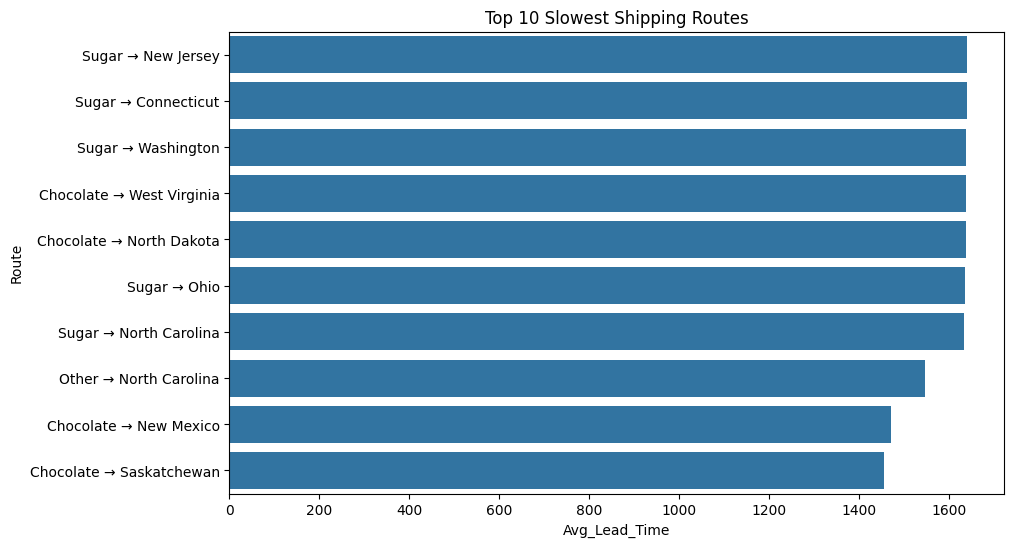

In [13]:
plt.figure(figsize=(10,6))
sns.barplot(data=slowest_routes.head(10), x='Avg_Lead_Time', y='Route')
plt.title("Top 10 Slowest Shipping Routes")
plt.show()

In [14]:
# Saved route data in a new csv file

df.to_csv("../data/processed/route_efficiency_data.csv", index=False)

## Conclusion of Data Preparation Phase

The dataset has been:
- Validated
- Cleaned
- Feature engineered
- Structured for route-level efficiency analysis

Next phase: Visualization & Geographic Bottleneck Analysis.